# Calculate the metrics from the csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

In [3]:
# --- Define models and their respective CSV paths ---
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_closed_image/closed_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_closed_image/closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")


Processing DINOv2 (Video)


-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 32.73it/s]



Processing DINOv2 (Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 33.64it/s]


...

100%|██████████| 100/100 [00:03<00:00, 27.38it/s]



Processing ViT (Video)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 34.55it/s]



Processing ViT (Image)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


100%|██████████| 100/100 [00:02<00:00, 34.79it/s]


In [4]:

# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename for results
FILENAME = f"closed_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print("✅ Results saved successfully.")


-> Saving all results to results_data/closed_world_benchmarks.pkl...
✅ Results saved successfully.


In [5]:
# Load the saved data
LOAD_PATH = "results_data/closed_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")


Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [6]:
# --- Print results ---
print("\n" + "="*115)
print(f"{'Model':<25} | {'mAP [95% CI]':<28} | {'Rank-1 [95% CI]':<28} | {'Rank-5 [95% CI]':<28}")
print("="*115)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    #  Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<25} | {map_str:<28} | {r1_str:<28} | {r5_str:<28}")

print("-" * 115)


Model                     | mAP [95% CI]                 | Rank-1 [95% CI]              | Rank-5 [95% CI]             
DINOv2 (Video)            | 0.544 [0.522-0.570]          | 0.583 [0.555-0.610]          | 0.782 [0.755-0.807]         
DINOv2 (Image)            | 0.443 [0.421-0.462]          | 0.448 [0.419-0.470]          | 0.666 [0.642-0.692]         
SwinV2 (Video)            | 0.285 [0.263-0.303]          | 0.271 [0.238-0.292]          | 0.519 [0.490-0.547]         
SwinV2 (Image)            | 0.214 [0.199-0.228]          | 0.201 [0.182-0.219]          | 0.389 [0.358-0.409]         
ViT (Video)               | 0.309 [0.286-0.326]          | 0.316 [0.288-0.336]          | 0.542 [0.511-0.569]         
ViT (Image)               | 0.225 [0.209-0.240]          | 0.207 [0.186-0.226]          | 0.413 [0.385-0.436]         
-------------------------------------------------------------------------------------------------------------------


/tmp/ipykernel_78651/27127669.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


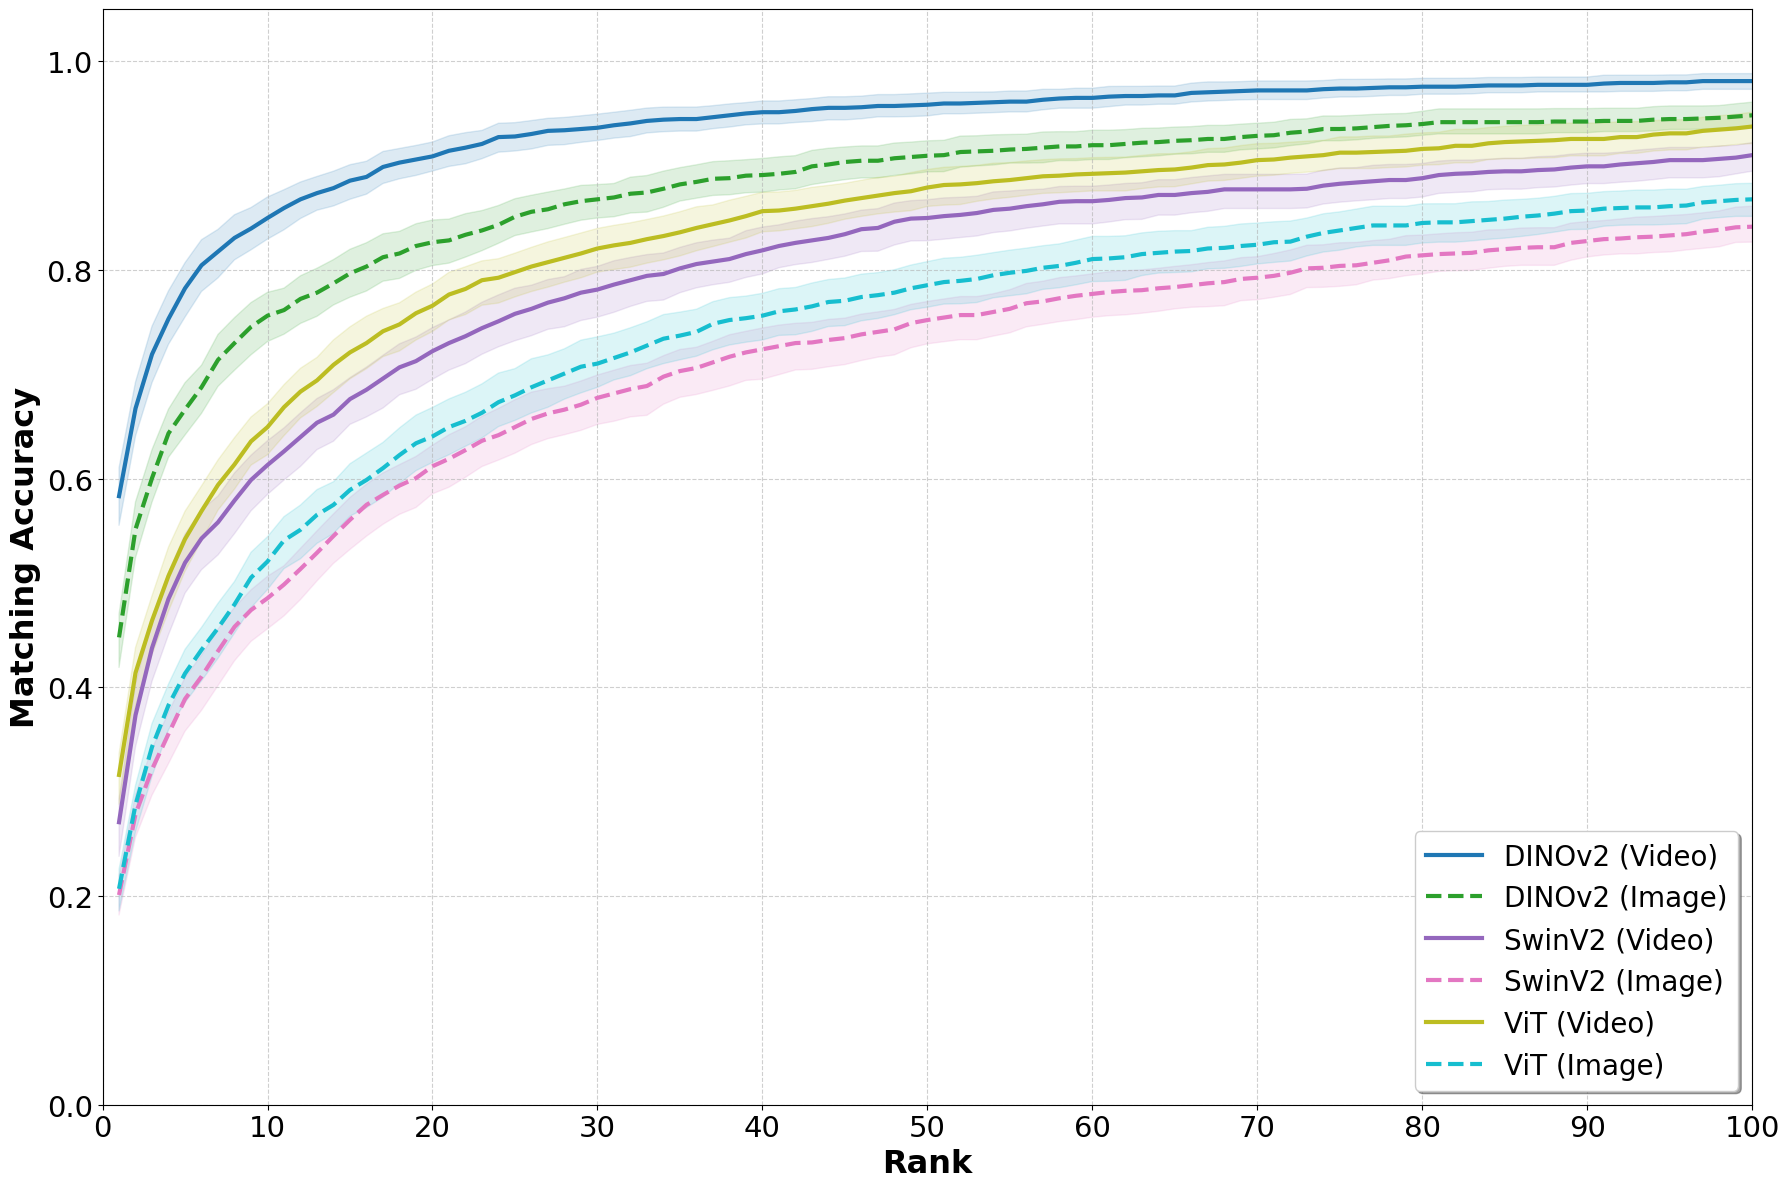

In [7]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# ------------------------------------------------------------- 
MAX_RANK = 100      
TICK_STEP = 10    
FONT_SIZE = 21       

# -------------------------------------------------------------
# --- Plotting CMC Curves with Confidence Intervals ---
# -------------------------------------------------------------

plt.figure(figsize=(18, 12))
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    # Using the ranks from the full set result
    ranks = np.arange(1, len(res["full_set"]["cmc"]) + 1)
    
    # Primary line: Full Set result
    cmc_full = res["full_set"]["cmc"]
    
    # Uncertainty: Bootstrap lower and upper bounds
    cmc_lower = res["cmc_ci_lower"]
    cmc_upper = res["cmc_ci_upper"]
    
    color = colors(i)
    
    # Plot the Shaded Uncertainty Interval (95% CI)
    plt.fill_between(ranks, cmc_lower, cmc_upper, color=color, alpha=0.15)
    
    # Plot the Full Set Line
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(ranks, cmc_full, color=color, linestyle=line_style, linewidth=3, 
             label=f"{name}")

# --- Format the Plot with Larger Fonts ---
plt.xlabel("Rank", fontsize=FONT_SIZE + 2, fontweight='bold')
plt.ylabel("Matching Accuracy", fontsize=FONT_SIZE + 2, fontweight='bold')

# --- Axis Tick Labels ---
plt.xticks(np.arange(0, MAX_RANK + 1, step=TICK_STEP), fontsize=FONT_SIZE)
plt.yticks(np.arange(0, 1.05, step=0.2), fontsize=FONT_SIZE)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_RANK) 
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend Configuration ---
# Placed in lower right as CMC curves typically trend upward
plt.legend(fontsize=FONT_SIZE - 1, loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/closed_world.png")
plt.show()

# Re-ID models

In [ ]:
# --- Define models and their respective CSV paths ---
models_to_test = {
    # --- MegaDescriptor (Baseline) ---
    "Mega (Vid2Vid)":   "csvs/megadescriptor_baseline_closed_attention_finetune_False_vid2vid/closed_dist_matrix.csv",
    "Mega (Img2Vid)":   "csvs/megadescriptor_baseline_closed_attention_finetune_False_img2vid/closed_dist_matrix.csv",
    "Mega (Img2Img)":   "csvs/megadescriptor_baseline_closed_attention_finetune_False_img2img/closed_dist_matrix.csv",

    # # --- MegaDescriptor (BoT) ---
    # "Mega BoT (Vid2Vid)": "csvs/megadescriptor_bot_closed_attention_finetune_False_vid2vid/closed_dist_matrix.csv",
    # "Mega BoT (Img2Vid)": "csvs/megadescriptor_bot_closed_attention_finetune_False_img2vid/closed_dist_matrix.csv",
    # "Mega BoT (Img2Img)": "csvs/megadescriptor_bot_closed_attention_finetune_False_img2img/closed_dist_matrix.csv",
    

    "TransReID (Vid2Vid)": "csvs/dinov2_transreid_closed_attention_finetune_False_vid2vid/closed_dist_matrix.csv",
    "TransReID (Img2Vid)": "csvs/dinov2_transreid_closed_attention_finetune_False_img2vid/closed_dist_matrix.csv",
    "TransReID (Img2Img)": "csvs/dinov2_transreid_closed_attention_finetune_False_img2img/closed_dist_matrix.csv",

    "DINOv2 (Video)":   "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)":   "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "DINOv2 (Img2Img)": "csvs/dinov2_closed_img2img/img2img_closed_dist_matrix.csv",
    "SwinV2 (Video)":   "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)":   "csvs/swin_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Img2Img)": "csvs/swin_closed_img2img/img2img_closed_dist_matrix.csv",
    "ViT (Video)":      "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":      "csvs/vit_closed_image/closed_dist_matrix.csv",
    "ViT (Img2Img)":    "csvs/vit_closed_img2img/img2img_closed_dist_matrix.csv",
    
    # --- BoT (DINOv2) ---
    "BoT (Vid2Vid)":    "csvs/bot_closed/closed_dist_matrix.csv",
    "BoT (Img2Vid)":    "csvs/bot_closed_image/closed_dist_matrix.csv",
    "BoT (Img2Img)":    "csvs/dinov2_bot_closed_attention_finetune_False_img2img/closed_dist_matrix.csv",
    
   
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")


# --- Print results ---
print("\n" + "="*115)
print(f"{'Model':<25} | {'mAP [95% CI]':<28} | {'Rank-1 [95% CI]':<28} | {'Rank-5 [95% CI]':<28}")
print("="*115)

for name, res in all_results.items():
    # mAP
    m_full = res['full_set']['mAP']
    m_low, m_high = res.get('mAP_ci', (m_full, m_full))
    map_str = f"{m_full:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    #  Rank-1 
    r1_full = res['full_set']['cmc'][0]
    r1_l = res.get('cmc_ci_lower', [r1_full])[0]
    r1_u = res.get('cmc_ci_upper', [r1_full])[0]
    r1_str = f"{r1_full:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-5 
    idx = 4 if len(res['full_set']['cmc']) >= 5 else -1
    r5_full = res['full_set']['cmc'][idx]
    r5_l = res.get('cmc_ci_lower', [r5_full])[idx]
    r5_u = res.get('cmc_ci_upper', [r5_full])[idx]
    r5_str = f"{r5_full:.3f} [{r5_l:.3f}-{r5_u:.3f}]"
    
    print(f"{name:<25} | {map_str:<28} | {r1_str:<28} | {r5_str:<28}")

print("-" * 115)


Processing Mega (Vid2Vid)
-> Calculating full set metrics (closed)...
-> Bootstrapping 'closed' metrics (100 iterations)...


 30%|███       | 30/100 [00:00<00:01, 56.84it/s]

100%|██████████| 100/100 [00:01<00:00, 56.42it/s]



Processing Mega (Img2Img)


FileNotFoundError: [Errno 2] No such file or directory: 'csvs/megadescriptor_baseline_closed_attention_finetune_False_img2img/closed_dist_matrix.csv'